# Stochastic Series Expansion for the Spin-1/2 Heisenberg Chain

- **Autor:** Théo HUET
- **Degree** Master 2 of Physics Thoeric
- **Institution** University of CY Cergy-Paris Université
- **Course** Quantum Monte Carlo, Andreas Honecker
- **Date** March, 2026

## 1. Introduction

### 1.1 Context and Motivation
The Stochastic Series Expansion (SSE) is a highly efficient Quantum Monte Carlo (QMC) method designed to study the thermodynamic properties of quantum lattice models at finite temperatures. Unlike methods based on the Suzuki-Trotter decomposition, SSE avoids systematic time-discretization errors by directly sampling the Taylor expansion of the partition function. This approach is essential for investigating many-body quantum systems where the Hilbert space grows exponentially, making exact diagonalization computationally impossible for large system sizes. By mapping the quantum problem onto a high-dimensional classical configuration space of operator sequences, SSE provides a powerful tool for obtaining high-precision results for magnetic and thermal observables.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

### 1.2 Theoretical Background
The core of this project is the study of the one-dimensional spin-1/2 Heisenberg model. The system is described by the following Hamiltonian:

$$H = J \sum_{i=1}^{L} \vec{S}_{i} \cdot \vec{S}_{i+1}$$

- where $L$ is the length of the chain and periodic boundary conditions are assumed, such that $L+1 \equiv 1$. Understanding this project requires familiarity with:
- **The Heisenberg Model:** A fundamental paradigm for describing exchange interactions between neighboring spins in magnetic materials.
- **Exchange Coupling ($J$):** The behavior of the system changes drastically depending on the sign of $J$, leading to either an Anti-ferromagnetic ($J=1$) or a Ferromagnetic ($J=-1$) ground state.
- **Magnetic Susceptibility ($\chi$):** A thermodynamic response function that characterizes how the magnetization of the system reacts to an external magnetic field, which we will compute as a function of temperature $T$.
- **Statistical Mechanics of SSE:** The representation of the partition function $Z = \text{Tr}(e^{-\beta H})$ as a summation over operator strings and spin states, with $\beta = \frac{1}{T k_B}$.

In [16]:
global L, J, beta

L = 100
J = 1. # Antiferro
beta = 1. # We gonna change it later

### 1.3 Objectives of the Project
The primary goal is to develop a robust numerical tool to simulate the magnetic properties of a 1D quantum spin chain. The specific objectives are:

1. **Algorithm Implementation:** Develop and implement the SSE algorithm tailored for the spin-1/2 Heisenberg chain.
2. **Thermodynamic Analysis:** Compute and plot the magnetic susceptibility $\chi(T)$ for both the anti-ferromagnetic ($J=1$) and ferromagnetic ($J=-1$) cases.
3. **Statistical Validation:** Implement rigorous thermalization protocols and estimate error bars by performing independent repetitions of the calculations to ensure the reliability of the results.

In [17]:
def init_spin_chain() -> np.ndarray: # random spin chain, we take 1 and -1 for efficency
    return np.random.choice([-1, 1], size=L)

def N_thermalisation(Nt) -> int: # The system needs to reach thermal equilibrium before we can calculate the quantities
  return int(0.2 * Nt)

def error(quantitie:list, n_runs:int) -> float: # for the error bar
    return np.std(quantitie) / np.sqrt(n_runs)

---

## 2. Theoretical Framework

### 2.1 The SSE Partition Function

The starting point for any thermodynamic study in the canonical ensemble is the partition function $Z$ at an inverse temperature $\beta = 1/k_B T$. For a quantum system governed by a Hamiltonian $H$, the partition function is defined as the trace of the density matrix:

$$Z = \text{Tr}(e^{-\beta H}) = \sum_{\alpha} \langle \alpha | e^{-\beta H} | \alpha \rangle$$

where $\{|\alpha\rangle\}$ is an orthonormal basis of the Hilbert space (typically the computational basis in the $S^z$ representation for spin systems). By expanding the exponential operator into its power series $e^{-\beta H}= \sum_{n=0}^{\infty} \frac{\beta^n}{n!}(-H)^n$, we obtain:

$$Z = \sum_{\alpha} \sum_{n=0}^{\infty} \frac{\beta^n}{n!} \langle \alpha | (-H)^n | \alpha \rangle$$

This formulation transforms the problem into a summation over all possible states $|\alpha\rangle$ and all possible expansion orders $n$. In a numerical simulation, the infinite sum is truncated at a sufficiently large cut-off $M$, such that the contribution of terms with $n > M$ is negligible.

### 2.2 The Configuration Space

In the SSE framework, the "configurations" sampled by the Monte Carlo algorithm are not just physical states, but pairs $(|\alpha\rangle, S_n)$, where:
* $|\alpha\rangle$ is an initial state of the basis.
* $S_n$ is an **operator string** consisting of a sequence of $n$ local components of the Hamiltonian $H$.

The weight of a specific configuration is determined by the matrix element $\langle \alpha | H^n | \alpha \rangle$. For this weight to be easily computable and non-negative (to avoid the infamous "sign problem"), we must decompose the global Hamiltonian $H$ into a sum of elementary, local bond operators.

This leads us to the necessity of rewriting our Heisenberg Hamiltonian in a form that distinguishes between diagonal and non-diagonal contributions.

### 2.3 Hamiltonian Decomposition and Sublattice Transformation
To implement the SSE, we decompose the Hamiltonian $H$ into a sum of local bond operators $H_{a,b}$, where $b$ denotes a bond $(i, i+1)$ and $a \in \{1, 2\}$ indicates the type of operator (diagonal or off-diagonal). We aim for a form:
$$-H = \sum_{b=1}^{L} (H_{1,b} + H_{2,b}) + \text{const}$$

Using the identity $\vec{S}_{i} \cdot \vec{S}_{j} = S_i^zS_j^z + \frac{1}{2} (S_i^+ S_j^- + S_i^- S_j^+)$, the Heisenberg Hamiltonian is:
$$H = J \sum_{i=1}^{L} \left[ S_i^z S_{i+1}^z + \frac{1}{2}(S_i^+ S_{i+1}^- + S_i^- S_{i+1}^+) \right]$$

For the **Ferromagnet** ($J=-1$), the terms in $-H$ are naturally positive. However, for the **Antiferromagnet** ($J=1$), the off-diagonal terms in $-H$ would be negative, leading to a sign problem. Since the 1D chain is a bipartite lattice, we apply a unitary transformation (a $\pi$-rotation around the $z$-axis) on one sublattice: $S_j^\pm \to -S_j^\pm$ and $S_j^z \to S_j^z$. This yields the following bond operators for both cases:

* **Diagonal Operator ($a=1$):** $H_{1,b} = \frac{1}{4} - S_i^z S_{i+1}^z$
* **Off-diagonal Operator ($a=2$):** $H_{2,b} = \frac{1}{2}(S_i^+ S_{i+1}^- + S_i^- S_{i+1}^+)$

This leads to the convenient form:
$$-H = \sum_{b=1}^L (H_{1,b} + H_{2,b}) - \frac{L}{4}$$

### 2.4 Positivity of Operator Weights
A crucial requirement for Monte Carlo sampling is that all configuration weights must be non-negative. Let's examine the action of our operators on the local basis $\{|\uparrow\uparrow\rangle, |\uparrow\downarrow\rangle, |\downarrow\uparrow\rangle, |\downarrow\downarrow\rangle\}$:

**For the Diagonal Operator $H_{1,b}$:**
* $H_{1,b} |\uparrow\uparrow\rangle = (\frac{1}{4} - \frac{1}{4}) |\uparrow\uparrow\rangle = 0$
* $H_{1,b} |\downarrow\downarrow\rangle = (\frac{1}{4} - \frac{1}{4}) |\downarrow\downarrow\rangle = 0$
* $H_{1,b} |\uparrow\downarrow\rangle = (\frac{1}{4} - (-\frac{1}{4})) |\uparrow\downarrow\rangle = \frac{1}{2} |\uparrow\downarrow\rangle$
* $H_{1,b} |\downarrow\uparrow\rangle = (\frac{1}{4} - (-\frac{1}{4})) |\downarrow\uparrow\rangle = \frac{1}{2} |\downarrow\uparrow\rangle$

**For the Off-diagonal Operator $H_{2,b}$:**
* $H_{2,b} |\uparrow\uparrow\rangle = 0$
* $H_{2,b} |\downarrow\downarrow\rangle = 0$
* $H_{2,b} |\uparrow\downarrow\rangle = \frac{1}{2} |\downarrow\uparrow\rangle$
* $H_{2,b} |\downarrow\uparrow\rangle = \frac{1}{2} |\uparrow\downarrow\rangle$

In all cases, the non-zero matrix elements are $\langle \alpha' | H_{a,b} | \alpha \rangle = 1/2$. The weights are strictly non-negative, ensuring a sign-problem-free simulation.

### 2.5 Fixed-Length Operator String Representation
To handle the summation over $n$ efficiently, we introduce a fixed-length expansion. We truncate the series at a maximum cutoff $M$ and fill the remaining $M-n$ slots with the identity operator $H_{0,0} \equiv I$. The number of ways to arrange $n$ operators in $M$ slots is given by the binomial coefficient $\binom{M}{n}$.

The partition function $Z$ is rewritten as:
$$Z = \sum_{\alpha} \sum_{S_M} \frac{\beta^n (M-n)!}{M!} \langle \alpha | \prod_{i=1}^{M} H_{a_i,b_i} | \alpha \rangle$$

where $S_M$ is the operator string of length $M$ containing $n$ active operators ($a>0$) and $M-n$ identities ($a=0$). The weight of a specific configuration $(\alpha, S_M)$ is thus:
$$W(\alpha, S_M) = \beta^n \frac{(M-n)!}{M!} \left( \frac{1}{2} \right)^n$$

This weight will be used in the Metropolis-Hastings updates to sample the configuration space.

---

## 3. Numerical Implementation

Moving from the theoretical expansion to a computational algorithm requires an efficient way to store and manipulate the sequence of operators.

### 3.1 Operator String Representation

The operator string $S_M$ is the central object of the SSE algorithm. We represent it using a one-dimensional NumPy array of fixed length $M$, where $M$ is the truncation cutoff of the Taylor expansion.

Initially, the string is populated with identity operators. To distinguish between the different types of operators (Identity, Diagonal, and Off-diagonal) and the specific bonds they act upon, we use an integer encoding scheme. Given a bond index $b \in \{0, 1, \dots, L-1\}$, the encoding is defined as follows:

* **Identity Operator ($H_{0,0}$):** Represented by `-1`.
* **Diagonal Operator ($H_{1,b}$):** Represented by an even integer $2b$.
* **Off-diagonal Operator ($H_{2,b}$):** Represented by an odd integer $2b + 1$.

In this convention, the bond index $b$ can be retrieved easily via integer division.

Each integer in the `op_string` (if not -1) points to a specific bond $b$ connecting two sites $(i, j)$ in the 1D chain. With periodic boundary conditions, site $i$ is connected to $j = (i+1) \pmod L$.

This representation is highly efficient for the Monte Carlo updates, as checking whether an operator is diagonal or off-diagonal simply requires checking the parity of the integer, and the identity operator is handled as a special case.


In [29]:
def init_op_strings(M:int) -> np.ndarray :
  return -np.ones(M, dtype=int)  # all are -1 : identity

def compute_bond(op_string_p:float) :
  assert op_string_p != -1 # identity
  bond = op_string_p // 2
  return bond, (bond + 1) % L

---

### 3.2 Diagonal Update

The diagonal update is the primary mechanism for changing the expansion order $n$ in the Stochastic Series Expansion. In this step, we explore different operator string lengths by attempting to insert or remove diagonal operators.

In this procedure, we iterate through all $M$ slots of the operator string. At each step, the action depends on the type of operator currently occupying the slot:

* **Identity Operator ($a=0$):** We propose replacing it with a diagonal operator. We randomly pick a bond $b$ from the $L$ possibilities. Since the diagonal operator only yields a non-zero matrix element for antiparallel spins, we first verify that the spins at the ends of the bond are antiparallel. If they are, we accept the insertion with a Metropolis probability based on the weight ratio : $\frac 12$ and the proposal probabilities.
$$P_{\text{insert}} = \min \left( 1, \frac{\beta J L}{2(M-n)} \right)$$
The factor of $1/2$ comes directly from the matrix element of the local bond operator acting on an antiparallel spin pair, while the factor $L$ accounts for the selection probability of choosing one bond out of the $L$ available in the system.

* **Diagonal Operator ($a=1$):** We propose replacing it with an identity operator. The removal is accepted with the corresponding reverse Metropolis probability.
$$P_{\text{remove}} = \min \left( 1, \frac{2(M-n+1)}{\beta J L} \right)$$
* **Off-Diagonal Operator ($a=2$):** During the diagonal update, off-diagonal operators are left untouched. However, we must flip the values of the two spins involved in the off-diagonal operator to correctly propagate the state $|\alpha\rangle$ for the subsequent slots in the loop.

We only insert and remove diagonal operators because they act on the local state without altering the spin configuration. This local property makes them ideal for simple Metropolis steps. Off-diagonal operators, which create kinks in the spin trajectories, are much more efficiently updated using non-local cluster updates (such as loop updates) that flip entire connected pathways of spins and operators simultaneously.

In [19]:
def insertion(op_string:np.ndarray, M:int, n:int, p:int, bond:int) ->int:
    if n == M : #impossible de faire l'insertion
        return n
    else :
        prob = (beta * J*L) / (2. * (M - n))
    if np.random.rand() <  min(1., prob):
        op_string[p] = 2 * bond
        n += 1
    return n

def remove(op_string:np.ndarray, M:int, n:int, p:int) ->int:
    prob = (2. *(M - n + 1)) / (beta * J * L)
    if np.random.rand() <  min(1., prob):
        op_string[p] = -1
        n -= 1
    return n

def diagonal_update(spins:np.ndarray, op_string:np.ndarray, M:int, n:int) -> int:
    spins_p = spins.copy()
    for p in range(M):
        op = op_string[p]
        if op == -1 : # identity
            bond = np.random.randint(0, L)
            i = bond
            j = (bond + 1) % L

            if spins_p[i] != spins_p[j]: # insertion possible?
                n = insertion(op_string, M, n, p, bond)

        elif op % 2 == 0 : # diagonal
            n = remove(op_string, M, n, p)
        else : # off-diagonal
            i, j = compute_bond(op)
            spins_p[i] *= -1
            spins_p[j] *= -1
    return n

---

### 3.3 Linked Vertex List

In [20]:
def connexion(site:int, last_leg:np.ndarray, first_leg:np.ndarray, links:np.ndarray, leg_in:int, leg_out:int):
    """connecter entrée actuelle à sortie précédent
    mettre à jour la sortie"""
    if last_leg[site] == -1: # si première occurrence
        first_leg[site] = leg_in
    else: # si déja vu
        prev = last_leg[site]
        links[leg_in] = prev
        links[prev] = leg_in

    last_leg[site] = leg_out

def compute_link_list(op_string:np.ndarray, M:int) -> np.ndarray:
    links = -np.ones(4*M, dtype=int) # leg non connecté = -1

    last_leg = np.full(L, -1)
    first_leg = np.full(L, -1)

    for p in range(M):
        # legs index
        leg0 = 4*p + 0  # i entrée
        leg1 = 4*p + 1  # j entrée
        leg2 = 4*p + 2  # i sortie
        leg3 = 4*p + 3  # j sortie

        op = op_string[p]
        if op == -1: # ignore les identitées car elle ne créent pas de vertex
            continue
        elif op % 2 == 0: # diagonal
            links[leg0] = leg2
            links[leg2] = leg0

            links[leg1] = leg3
            links[leg3] = leg1
        else: # off-diagonal
            links[leg0] = leg3
            links[leg3] = leg0

            links[leg1] = leg2
            links[leg2] = leg1

        i, j = compute_bond(op)

        connexion(i, last_leg, first_leg, links, leg_in=leg0, leg_out=leg2)
        connexion(j, last_leg, first_leg, links, leg_in=leg1, leg_out=leg3)

    for site in range(L): # fermeture periodique
        if first_leg[site] != -1:
            links[first_leg[site]] = last_leg[site]
            links[last_leg[site]] = first_leg[site]
    return links

In [21]:
"""def connexion(site:int, last_leg:np.ndarray, first_leg:np.ndarray, links:np.ndarray, leg_in:int, leg_out:int):
    if last_leg[site] == -1: # si première occurrence
        first_leg[site] = leg_in
    else: # si déja vu
        prev = last_leg[site]
        links[prev] = leg_in
        links[leg_in] = prev

    last_leg[site] = leg_out

def compute_link_list(op_string:np.ndarray, M:int) -> np.ndarray:
    links = -np.ones(4*M, dtype=int) # leg non connecté = -1

    last_leg = np.full(L, -1)
    first_leg = np.full(L, -1)

    for p in range(M):
        op = op_string[p]
        if op == -1:
            continue

        leg0 = 4*p + 0
        leg1 = 4*p + 1
        leg2 = 4*p + 2
        leg3 = 4*p + 3

        if op % 2 == 0:
            # diagonal
            links[leg0] = leg2
            links[leg2] = leg0

            links[leg1] = leg3
            links[leg3] = leg1
        else:
            # off-diagonal
            links[leg0] = leg3
            links[leg3] = leg0

            links[leg1] = leg2
            links[leg2] = leg1

        i, j = compute_bond(op)

        connexion(i, last_leg, first_leg, links, leg_in=leg0, leg_out=leg2)
        connexion(j, last_leg, first_leg, links, leg_in=leg1, leg_out=leg3)

    for site in range(L): # fermeture periodique
        if first_leg[site] != -1:
            links[first_leg[site]] = last_leg[site]
            links[last_leg[site]] = first_leg[site]
    # for i in range(4*M):
    #   assert links[i] != -1
    #   assert links[links[i]] == i
    return links"""

'def connexion(site:int, last_leg:np.ndarray, first_leg:np.ndarray, links:np.ndarray, leg_in:int, leg_out:int):\n    if last_leg[site] == -1: # si première occurrence\n        first_leg[site] = leg_in\n    else: # si déja vu\n        prev = last_leg[site]\n        links[prev] = leg_in\n        links[leg_in] = prev\n\n    last_leg[site] = leg_out\n\ndef compute_link_list(op_string:np.ndarray, M:int) -> np.ndarray:\n    links = -np.ones(4*M, dtype=int) # leg non connecté = -1\n\n    last_leg = np.full(L, -1)\n    first_leg = np.full(L, -1)\n\n    for p in range(M):\n        op = op_string[p]\n        if op == -1:\n            continue\n\n        leg0 = 4*p + 0\n        leg1 = 4*p + 1\n        leg2 = 4*p + 2\n        leg3 = 4*p + 3\n\n        if op % 2 == 0:\n            # diagonal\n            links[leg0] = leg2\n            links[leg2] = leg0\n\n            links[leg1] = leg3\n            links[leg3] = leg1\n        else:\n            # off-diagonal\n            links[leg0] = leg3\n    

---

### 3.4 Off-Diagonal (Loop) Update

Une loop flip = changer le type des vertex qu’elle traverse, pas juste les spins :

- parcourir les loops
- avec probabilité 1/2
- échanger diagonal ↔ off-diagonal
- reconstruire les spins, en effet il faut refaire une propagation sur les spins, on reconstruit les spins à partir de la string.

attention Chaque vertex apparaît 4 fois dans la loop Donc on va le flip 4 fois → revenir à l’état initial, il faut donc verifier si ils sont déja apparu

In [22]:
def leg_to_site(leg:int, op_string:np.ndarray) -> int:
  p = leg // 4
  leg_type = leg % 4
  b = op_string[p] // 2

  i = b
  j = (b+1) % L

  if leg_type in [0, 2]:
      return i
  else:
      return j

def loop_update(spins:np.ndarray, op_string:np.ndarray, links:np.ndarray, M:int) :
    visited_leg = np.zeros(4*M, dtype=bool)

    for start in range(4*M):
        # create the loop
        if visited_leg[start] or links[start] == -1:
            continue

        current = start
        loop_legs = []

        while True:
            visited_leg[current] = True
            loop_legs.append(current)

            assert links[links[current]] == current

            current = links[current] # suivre lien
            if current == start:
                break
        # flip
        if np.random.rand() < 0.5:
            vertices = set()# set permet deviter de passer plusieur fois sur le meme vertex
            visited_sites = set()# set permet deviter de passer plusieur fois sur le meme site
            # spins change
            for leg in loop_legs:
              p = leg // 4

              if op_string[p] == -1:
                  continue

              site = leg_to_site(leg, op_string)
              if site not in visited_sites:
                spins[site] *= -1
                visited_sites.add(site)

              vertices.add(p)

            #vertices change
            for p in vertices:
                # flip vertex
                if op_string[p] == -1:
                    continue
                elif op_string[p] % 2 == 0:
                    op_string[p] += 1   # diag → off-diag
                else:
                    op_string[p] -= 1   # off-diag → diag

---

## 4. Measure

### 4.1 Computation furmula

#### Energy

- $E = -\frac{\langle n\rangle}\beta + \frac{JL}4$

#### Magnetization

- $M = \sum_{i=1}^L s_i$

#### Susceptibility

- $\chi = \beta \frac {\langle M^2 \rangle} L$

Pour notre projet nous calculerons ces valeurs par spin donc elles seront divisé par L

In [23]:
def compute_energy(n:list)->float:
    return -np.mean(n) / beta + ((J*L)/4) # la constante de décalage

def compute_Magnetisation(spins:np.ndarray)->float:
    return np.sum(spins)

def compute_susceptibility(M:list)->float:
    return beta * np.mean(np.array(M)**2)

---

### 4.2 Theoric value

In [ ]:
E0_theoric = -0.4431

---

## 5. Simulation

In [24]:
def simulation(N_sweeps:int) :
    n_list, M_list = [], [] # liste de mesure

    #initialisation
    M = int(2 * beta * L)
    spins = init_spin_chain()
    op_string = init_op_strings(M)
    n = 0

    for step in range(N_sweeps):
        n = diagonal_update(spins, op_string, M, n)
        links = compute_link_list(op_string, M)
        loop_update(spins, op_string, links, M)

        if n > 0.8 * M:
            new_M = int(1.5 * M)

            new_op_string = -np.ones(new_M, dtype=int)
            new_op_string[:M] = op_string

            op_string = new_op_string
            M = new_M

        if step > N_thermalisation(N_sweeps):
            n_list.append(n)
            M_list.append(compute_Magnetisation(spins))

    return n_list, M_list

Since our simulations are random, we need to calculate averages across multiple simulations.

We will also be able to calculate the error bars.

In [25]:
def simulation_n_runs(n_runs:int, N_sweeps:int) :
    e_list, m_list, susceptibility_list = [], [], []
    for run in range(n_runs) :
        print(f"- run : {run+1}/{n_runs}")
        n_list, M_temp = simulation(N_sweeps)

        e_list.append(compute_energy(n_list)/L)
        m_list.append(np.mean(M_temp)/L)
        susceptibility_list.append(compute_susceptibility(M_temp)/L)
    return e_list, m_list, susceptibility_list

---

### 5.1 Multiple temperatures simulation

We will therefore simulate the 1D Ising model for several temperature values to see if we can reproduce the theoretical values of this model.

In [26]:
N_sweeps = 5000
n_runs = 3

temp_list = np.linspace(0.1,2, 7)
beta_list = (1/temp_list).round(4) #kb=1

e_list, m_list, susceptibility_list = [], [], []
e_error, m_error, s_error = [], [], []
for beta in beta_list :
    print(f"beta={beta}")
    e_temp, m_temp, susceptibility_temp = simulation_n_runs(n_runs, N_sweeps)

    e_list.append(np.mean(e_temp))
    m_list.append(np.mean(m_temp))
    susceptibility_list.append(np.mean(susceptibility_temp))

    e_error.append(error(e_temp, n_runs))
    m_error.append(error(m_temp, n_runs))
    s_error.append(error(susceptibility_temp, n_runs))



beta=10.0
- run : 1/3
- run : 2/3
- run : 3/3
beta=2.4
- run : 1/3
- run : 2/3
- run : 3/3
beta=1.3636
- run : 1/3
- run : 2/3
- run : 3/3
beta=0.9524
- run : 1/3
- run : 2/3
- run : 3/3
beta=0.7317
- run : 1/3
- run : 2/3
- run : 3/3
beta=0.5941
- run : 1/3
- run : 2/3
- run : 3/3
beta=0.5
- run : 1/3
- run : 2/3
- run : 3/3


---

### 5.2 Plot

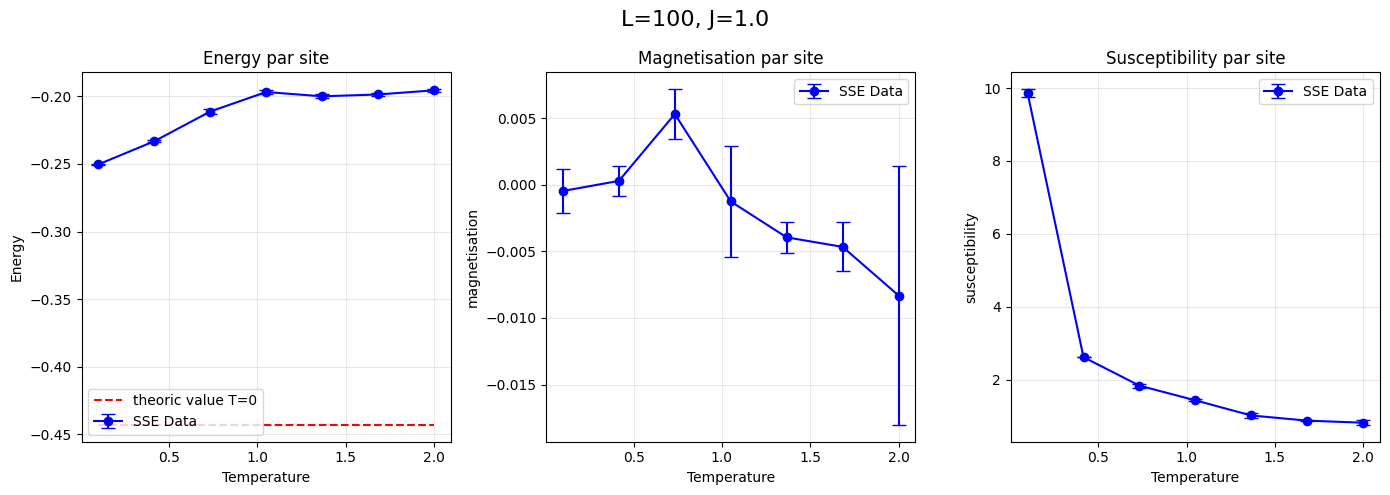

In [27]:
x_min = min(temp_list)
x_max = max(temp_list)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

ax1.errorbar(temp_list, e_list, yerr=e_error, fmt='o-',
              color='blue', capsize=5, label='SSE Data')
ax1.hlines(E0_theoric, x_min,  x_max, linestyle='--', color='red', label='theoric value T=0')
ax1.set_title(f"Energy par site")
ax1.set_xlabel("Temperature")
ax1.set_ylabel("Energy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.errorbar(temp_list, m_list, yerr=m_error, fmt='o-',
              color='blue', capsize=5, label='SSE Data')
#ax2.hlines(m_theoric, x_min,  x_max, linestyle='--', color='red', label='theoric value')
ax2.set_title(f"Magnetisation par site")
ax2.set_xlabel("Temperature")
ax2.set_ylabel("magnetisation")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.errorbar(temp_list, susceptibility_list, yerr=s_error, fmt='o-',
              color='blue', capsize=5, label='SSE Data')
#ax3.hlines(susceptibility_theoric, x_min,  x_max, linestyle='--', color='red', label='theoric value')
ax3.set_title(f"Susceptibility par site")
ax3.set_xlabel("Temperature")
ax3.set_ylabel("susceptibility")
ax3.legend()
ax3.grid(True, alpha=0.3)

fig.suptitle(f"L={L}, J={J}", fontsize=16)
plt.tight_layout()
plt.show()

---

### 4.3 Observation

---

### 4.4 Conclusion